In [ ]:

from skimage import io, color, morphology, filters, data, exposure, segmentation, measure
from matplotlib import pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans, vq

In [ ]:

def plot(img, is_color=False):
    plt.figure(figsize=(8,8))
    if is_color:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap = plt.cm.gray)

def plot_subplots(img1, img2):
    plt.figure(figsize=(12,12))
    plt.subplot(1,2,1)
    plt.imshow(img1, cmap = plt.cm.gray)
    plt.subplot(1,2,2)
    plt.imshow(img2, cmap = plt.cm.gray)
    plt.show()

Wgrywamy zdjęcie:



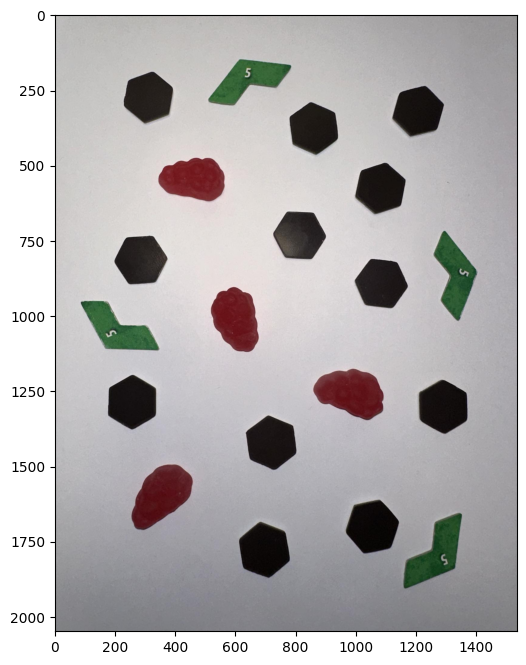

In [ ]:
img = io.imread('obraz.jpg')
plot(img, True)

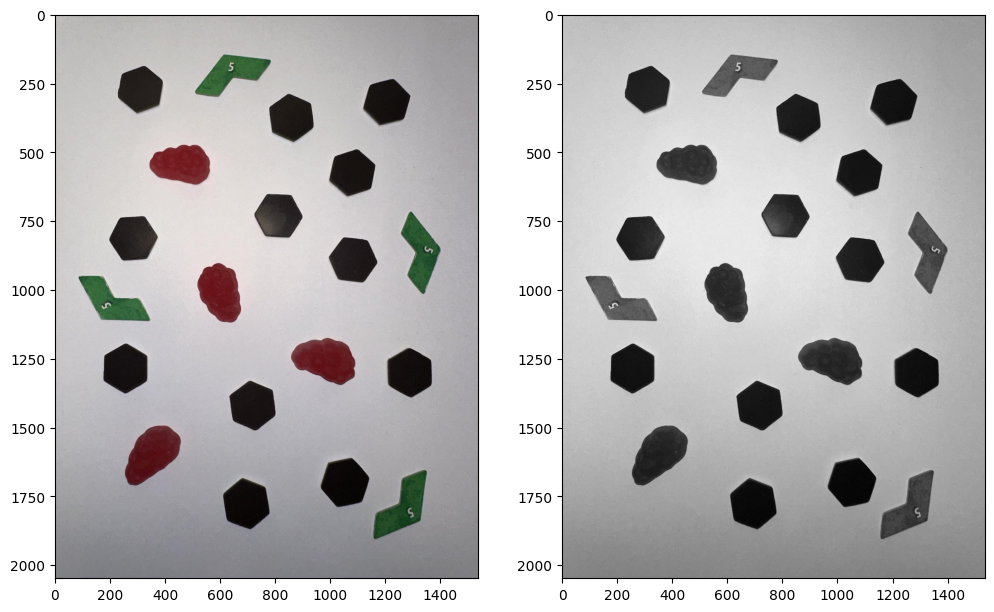

In [ ]:
img_gray = color.rgb2gray(img)
plot_subplots(img, img_gray)

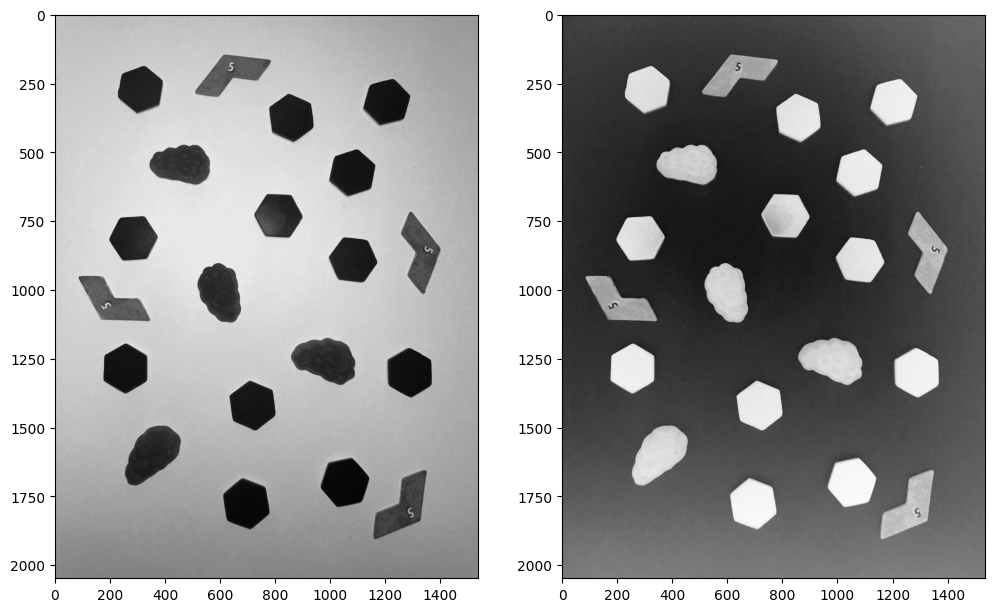

In [ ]:
img_negative = 1-img_gray
plot_subplots(img_gray, img_negative)

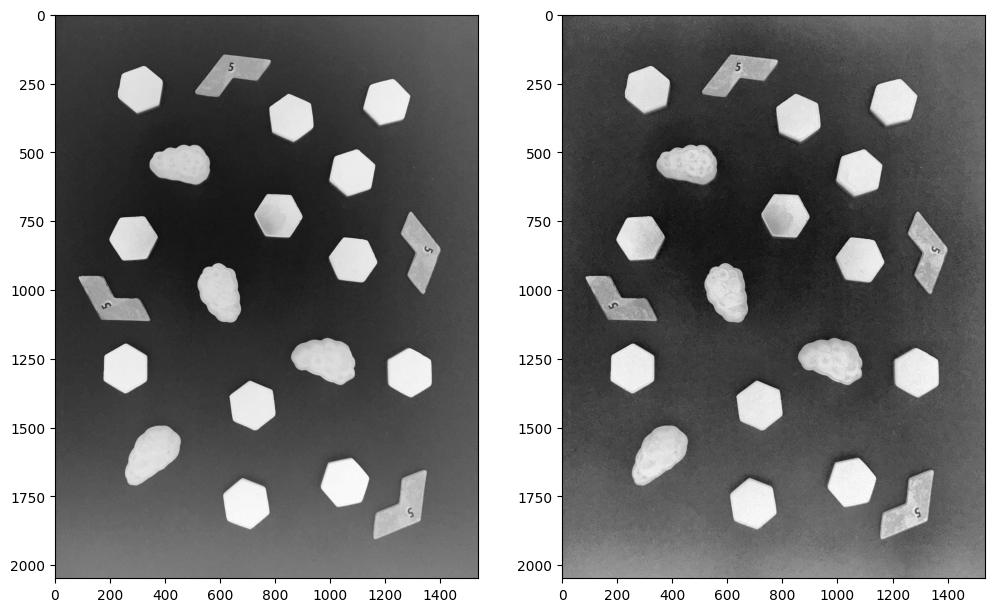

In [ ]:
img_equalized = exposure.equalize_adapthist(img_negative)
img_equalized = (img_equalized*255).astype('uint8')
plot_subplots(img_negative, img_equalized)

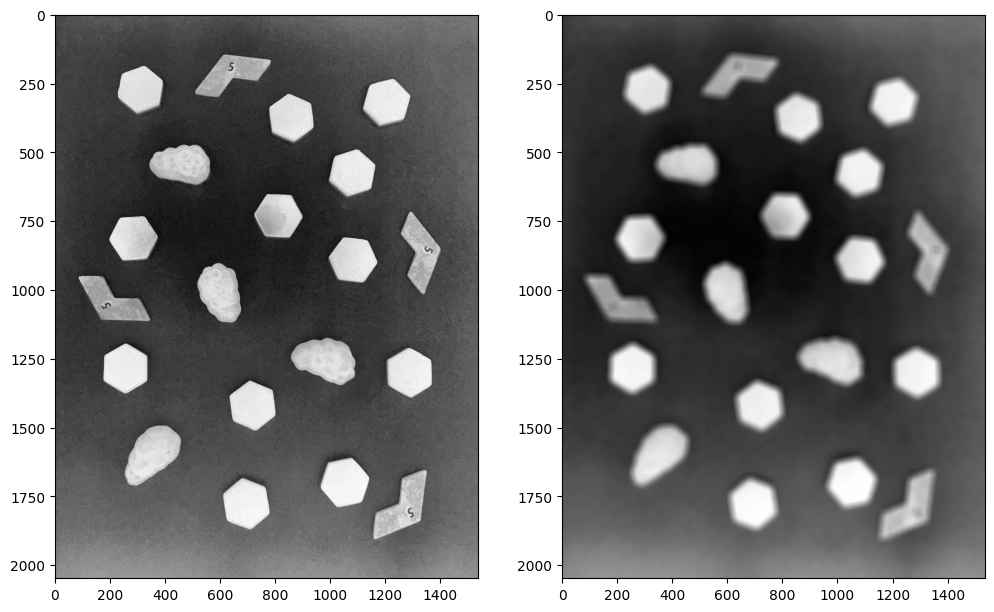

In [ ]:
img_filtered = filters.rank.mean(img_equalized, np.ones([31,31]))
plot_subplots(img_equalized, img_filtered)

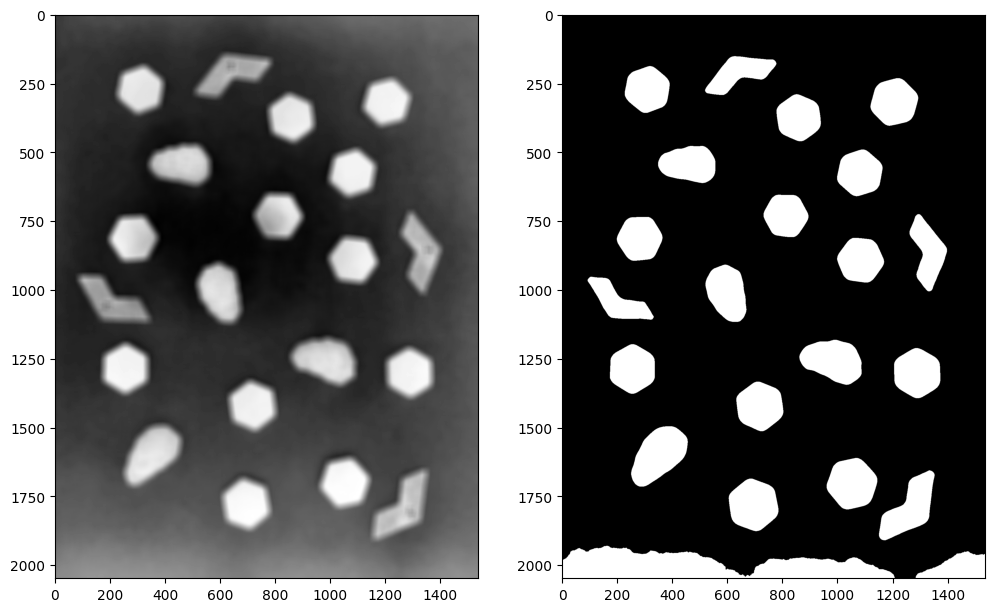

In [ ]:
threshold = filters.threshold_otsu(img_filtered)
img_bin = img_filtered > threshold
plot_subplots(img_filtered, img_bin)

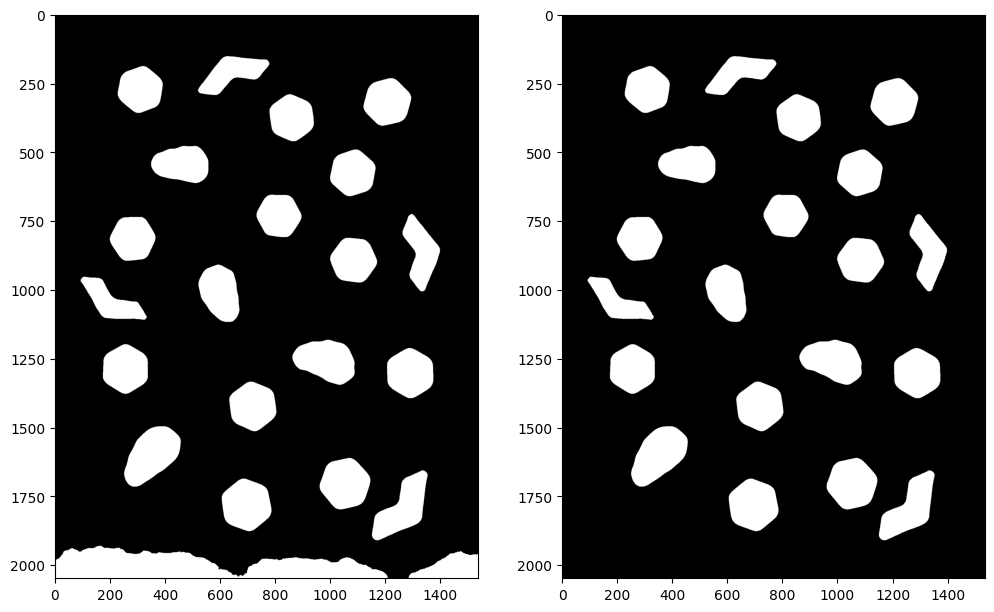

In [ ]:
img_cleared_borders = segmentation.clear_border(img_bin)
plot_subplots(img_bin, img_cleared_borders)

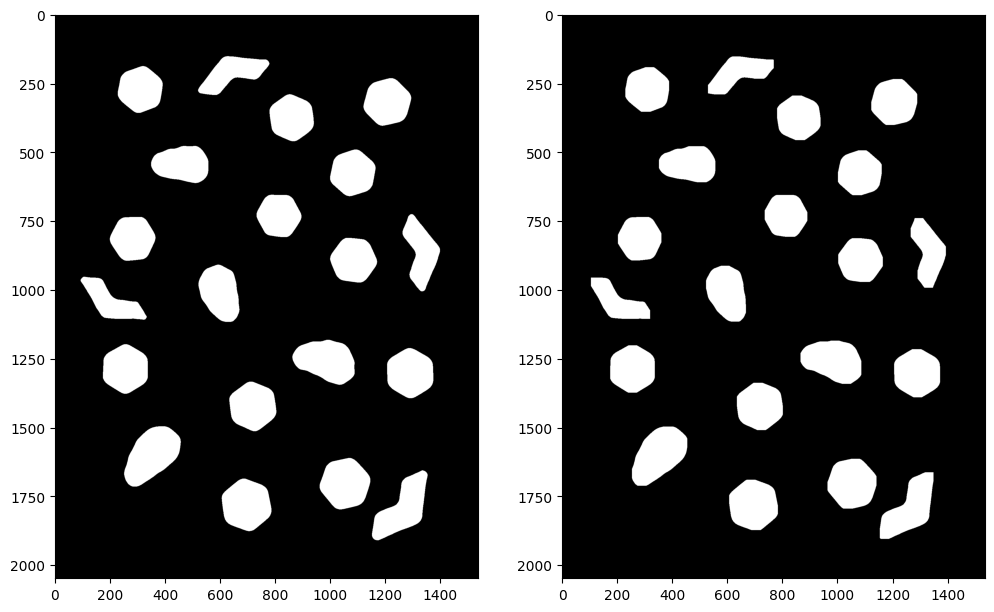

In [ ]:
img_opened = morphology.binary_opening(img_cleared_borders, np.ones([31,31]))
plot_subplots(img_cleared_borders, img_opened)

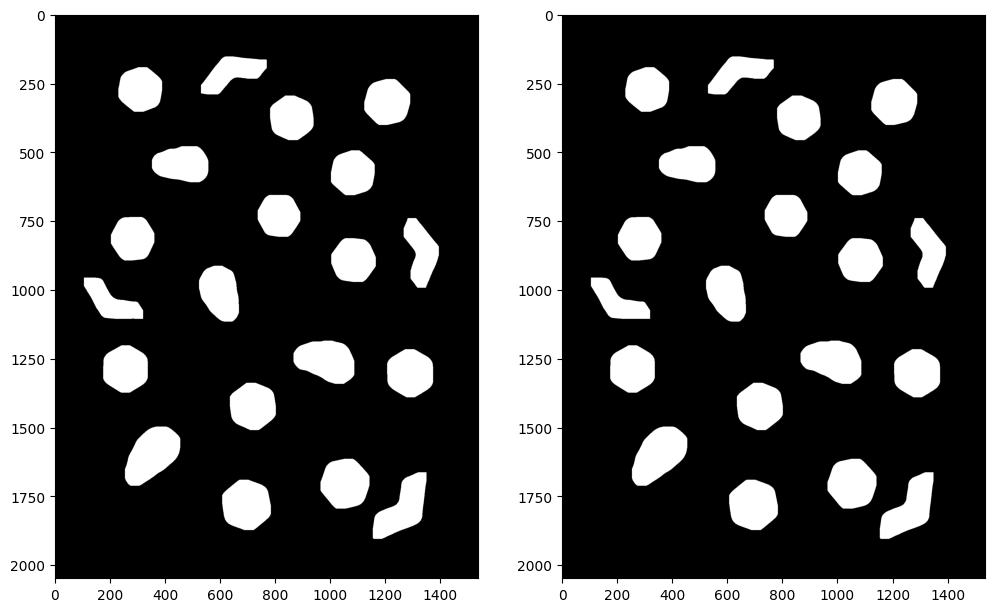

In [ ]:
img_preprocessed = morphology.binary_closing(img_opened, np.ones([11,11]))
plot_subplots(img_opened, img_preprocessed)

In [ ]:
#Ta funkcja oblicza współczynnik prostokątności obiektu. Współczynnik ten jest stosunkiem pola powierzchni obiektu do pola powierzchni najmniejszego prostokąta otaczającego
def calc_rectangularity(area, bbox_area):
    return area/bbox_area

#Ta funkcja oblicza współczynnik zaokrąglenia obiektu. Współczynnik ten mierzy, jak bardzo obiekt przypomina kształt koła. Im większa wartość współczynnika zaokrąglenia, tym bardziej obiekt jest zbliżony do kształtu koła.
def calc_roundness(area, perimeter):
    return (4*np.pi*area)/perimeter**2

#Ta funkcja oblicza współczynnik wydłużenia obiektu. Współczynnik ten mierzy stosunek długości do szerokości obiektu. Im większa wartość współczynnika wydłużenia, tym bardziej obiekt jest wydłużony w jednym kierunku. Wartość współczynnika wydłużenia wynosi 0 dla obiektów idealnie okrągłych i zwiększa się wraz z rozciągnięciem obiektu.
def calc_elongation(bbox_width, bbox_length):
    return 1 - bbox_width/bbox_length

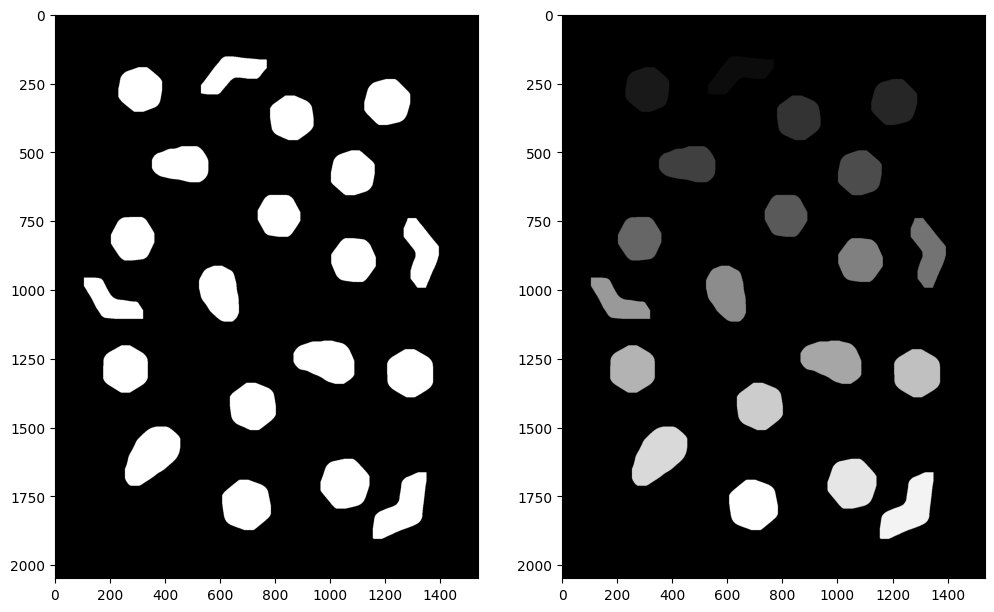

In [ ]:
img_labeled = measure.label(img_preprocessed, connectivity=2)
plot_subplots(img_preprocessed, img_labeled)

In [ ]:
regionprops = measure.regionprops(img_labeled)

In [ ]:
labels = np.unique(img_labeled)[1:]
print(labels)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [ ]:
#Tworzymy wektory cech dla obiektów na obrazie na podstawie ich własności geometrycznych i kolorów.
feature_vectors = []
for label, rp in zip(labels, regionprops):
    # get object of specific label
    obj = img_labeled == label
    # roundness
    roundness = calc_roundness(rp.area, rp.perimeter)
    # rectangularity
    rectangularity = calc_rectangularity(rp.area, rp.bbox_area)
    # elongation
    elongation = calc_elongation(rp.bbox[3] - rp.bbox[2], rp.bbox[1] - rp.bbox[0])
    # R color channel
    red_color = img[:,:,0][obj].mean()
    # G color channel
    green_color = img[:,:,1][obj].mean()
    # construct feature vector
    feature_vector = [roundness, rectangularity, elongation, red_color, green_color]

    # add feature vector to the list containing feature vectors of the other objects
    feature_vectors.append(feature_vector)

In [ ]:
feature_vectors = np.array(feature_vectors)

In [ ]:
#Grupowanie obiektów
# initial_k = np.stack([feature_vectors[10], feature_vectors[12], feature_vectors[14]])
initial_k = 3
centroids, _ = kmeans(feature_vectors, k_or_guess=initial_k, iter=20000, thresh=0.01)
print(centroids)

[[ 5.51491237e-01  5.56459820e-01 -1.15968915e-02  4.93981005e+01
   9.20514585e+01]
 [ 9.02486836e-01  8.00374822e-01 -5.92396355e-02  3.48503937e+01
   3.04008914e+01]
 [ 8.10428606e-01  7.49401920e-01  1.54633346e-01  1.04371161e+02
   3.10033875e+01]]


In [ ]:
#Podaje ilość znalozionych (wsztstich) obiektów
classes, _ = vq(feature_vectors, centroids)
print(classes)

[0 1 1 1 2 1 1 1 0 1 2 0 2 1 1 1 2 1 0 1]


In [ ]:
masks = {}
for c in np.unique(classes):
    mask = np.zeros(img_labeled.shape)
    for label in labels[classes == c]:
        mask += img_labeled == label
    masks = {**masks, c: mask.astype(bool)}

In [ ]:
#Nakładamy maskę(kolor) dla poszczególne rodzaje obiektów
def mark_objects(img, mask, colors):
    img_copy = img.copy()
    img_copy[mask, 0] = colors[0]
    img_copy[mask, 1] = colors[1]
    img_copy[mask, 2] = colors[2]
    plt.figure(figsize=(16,24))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.subplot(1,3,2)
    plt.imshow(mask, cmap=plt.cm.gray)
    plt.subplot(1,3,3)
    plt.imshow(img_copy)
    plt.show()

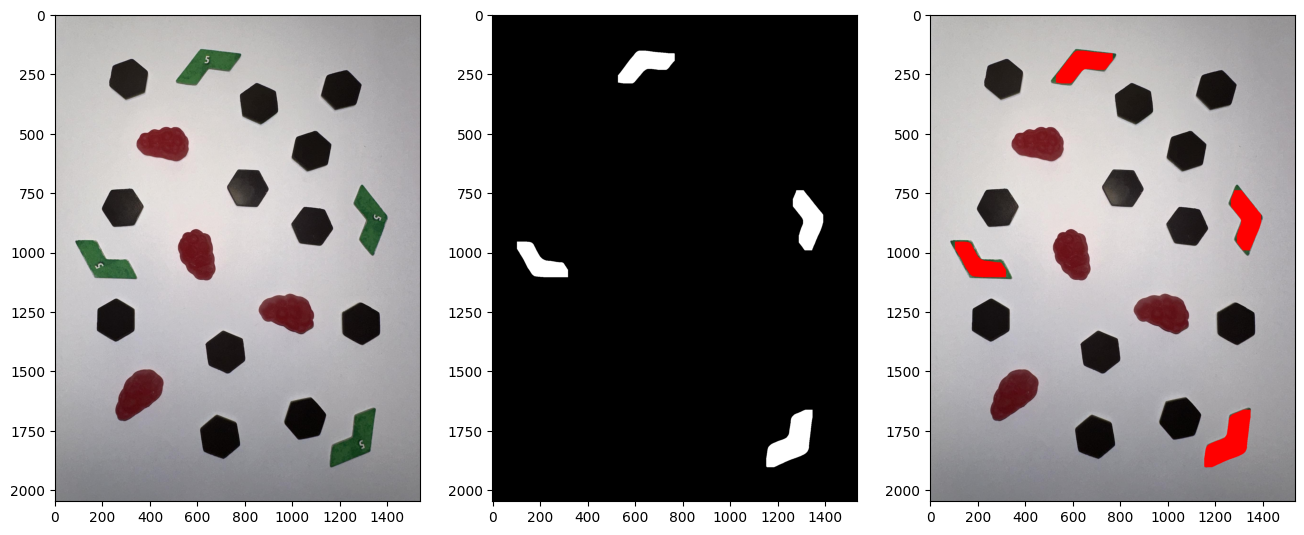

In [ ]:
mark_objects(img, masks[0], (255,0,0))

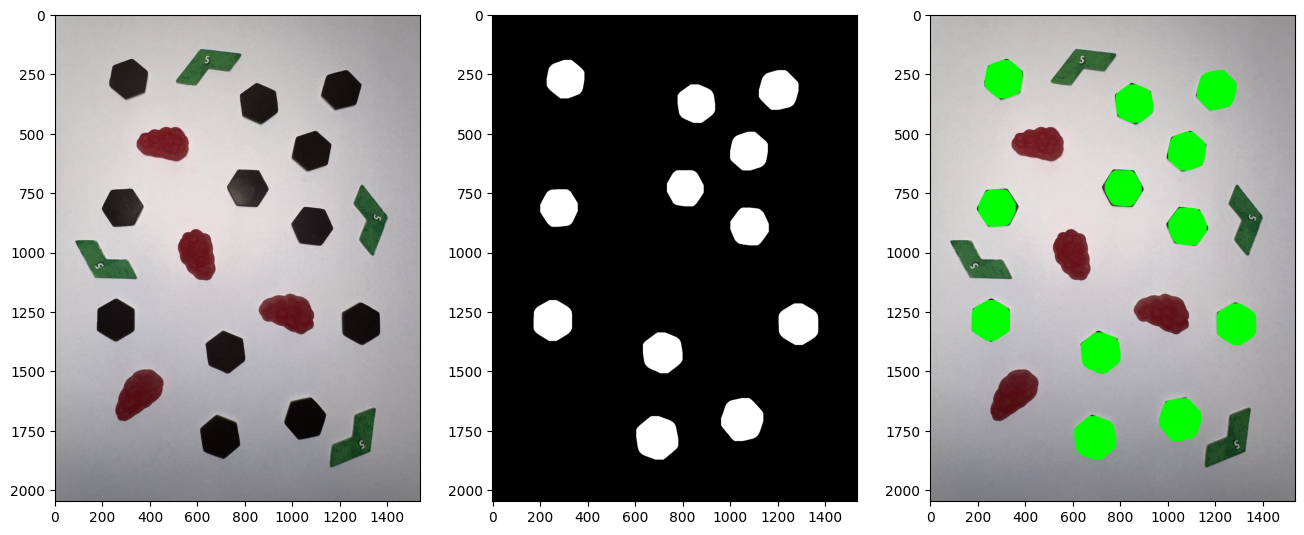

In [ ]:
mark_objects(img, masks[1], (0,255,0))

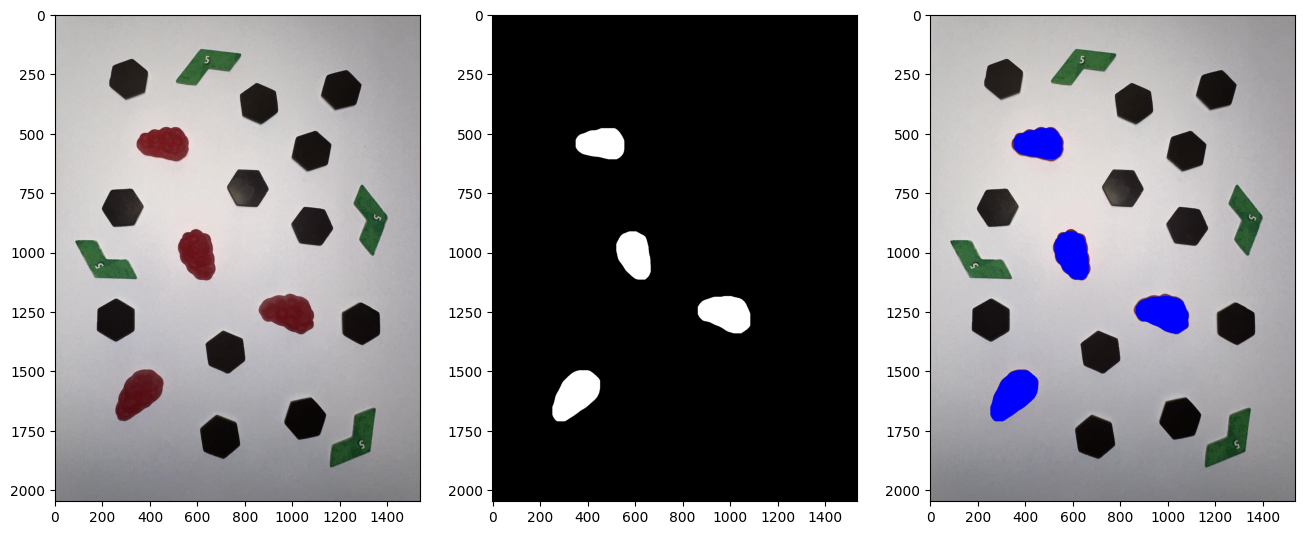

In [ ]:
mark_objects(img, masks[2], (0,0,255))